<a href="https://colab.research.google.com/github/AlvaroRg-bot/redessociales/blob/main/analisisredessociales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORTAMOS LIBRERIAS

In [ ]:
pip install googletrans==4.0.0-rc1

In [ ]:
import kagglehub
import os
import pandas as pd # Necesario para el paso final
import matplotlib.pyplot as plt
import seaborn as sns




#IMPORTAMOS CONJUNTO DE DATOS DIRECTO DE KAGLE
[Conjunto de datos de redes sociales](https://www.kaggle.com/datasets/jocelyndumlao/social-media-and-consumer-behavior-2025)

In [ ]:

# Download latest version

path = kagglehub.dataset_download("jocelyndumlao/social-media-and-consumer-behavior-2025")
print("Path to dataset files:", path)
# Asume que 'path' es la ruta principal de descarga
# Ejemplo: path = '/content/kaggle/jocelyndumlao/social-media-and-consumer-behavior-2025/1'

contenido_inicial = os.listdir(path)
print("Contenido inicial (debería ser la subcarpeta):", contenido_inicial)

# Asumimos que el primer elemento de la lista es la subcarpeta
if contenido_inicial:
    nombre_subcarpeta = contenido_inicial[0]

    # Construir la ruta a la subcarpeta
    nueva_ruta = os.path.join(path, nombre_subcarpeta)
    print(f"\nSe ha detectado una subcarpeta: **{nombre_subcarpeta}**")

# Listar el contenido de la subcarpeta
archivos_finales = os.listdir(nueva_ruta)
print("\nArchivos dentro de la subcarpeta:")
for archivo in archivos_finales:
    print(archivo)


nombre_archivo_csv='Impacto dos Algoritmos das Redes Sociais no Comportamento de Consumo em Rondon do Pará.csv'
# Unir la ruta de la subcarpeta con el nombre del archivo CSV
ruta_completa_csv = os.path.join(nueva_ruta, nombre_archivo_csv)

# Cargar el archivo en un DataFrame de Pandas
try:
    df_redesSociales = pd.read_csv(ruta_completa_csv)
    print("\n¡Carga exitosa del DataFrame!")
except FileNotFoundError:
    print(f"\nERROR: No se encontró el archivo '{nombre_archivo_csv}' en la ruta: {nueva_ruta}. Verifica el nombre.")

100%|██████████| 5.10k/5.10k [00:00<00:00, 8.90MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jocelyndumlao/social-media-and-consumer-behavior-2025/versions/1
Contenido inicial (debería ser la subcarpeta): ['Dataset on the Impact of Social Media Algorithms o']

Se ha detectado una subcarpeta: **Dataset on the Impact of Social Media Algorithms o**

Archivos dentro de la subcarpeta:
Impacto dos Algoritmos das Redes Sociais no Comportamento de Consumo em Rondon do Pará.csv

¡Carga exitosa del DataFrame!


# PREPROCESAMOS LA INFORMACIÓN

In [ ]:
df_redesSociales

,Carimbo de data/hora,Caracterização Sociodemográficas.,2- Sexo:,3- Escolaridade,4- Ocupação principal:,5- Renda mensal pessoal aproximada:,Uso de Redes Sociais,7- Tempo médio diário de uso das redes sociais,8- Com que frequência você visualiza anúncios nas redes sociais?,9- Você já realizou alguma compra após ver um anúncio nas redes sociais?,...,19- Já comprei produtos com base em recomendações de influenciadores nas redes sociais.,Comportamento de Consumo Online,21- O preço é o principal fator que me leva a optar por compras online.,22- A praticidade das compras online me faz comprar com mais frequência.,23- Considero as avaliações e comentários de outros consumidores antes de comprar.,24- Já deixei de comprar em loja física porque encontrei melhor oferta nas redes sociais.,Comércio Local e Percepções Finais,26- Gostaria que as lojas locais utilizassem mais as redes sociais para divulgar seus produtos.,"27- Se as lojas locais anunciassem de forma personalizada, eu compraria delas.",28- As redes sociais podem ser usadas de forma positiva para fortalecer o comércio local.
0,2025/10/14 4:26:09 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram;TikTok,Entre 1 e 3 horas,Às vezes,Sim,...,Concordo totalmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente
1,2025/10/14 4:28:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Entre 1 e 3 horas,Raramente,Não,...,Concordo totalmente,Discordo totalmente,Concordo totalmente,Concordo totalmente,Discordo totalmente;Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo parcialmente,Concordo totalmente
2,2025/10/14 4:32:40 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Desempregado,Até 1 salário mínimo,Instagram;TikTok;Facebook;YouTube,Entre 3 e 5 horas,Muito frequentemente,Sim,...,Concordo levemente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo totalmente
3,2025/10/14 4:33:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram,Entre 1 e 3 horas,Frequentemente,Sim,...,Concordo levemente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
4,2025/10/14 4:35:07 PM GMT-3,de 30 a 39 anos,Feminino,Ensino Superior,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Mais de 5 horas,Frequentemente,Sim,...,Concordo levemente,Concordo levemente,Concordo totalmente,Concordo levemente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo parcialmente,Concordo totalmente,Concordo totalmente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,2025/10/23 3:42:52 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Trabalhador assalariado,Até 1 salário mínimo,Instagram,Mais de 5 horas,Raramente,Sim,...,Discordo levemente,Concordo parcialmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo levemente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
90,2025/10/24 12:56:40 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Trabalhador assalariado,De 2 a 3 salários,Instagram,Entre 1 e 3 horas,Muito frequentemente,Sim,...,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
91,2025/10/27 3:23:46 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Acima de 3 salários,Instagram,Entre 3 e 5 horas,Frequentemente,Sim,...,Concordo levemente,Concordo totalmente,Concordo totalmente,Concordo totalme

In [ ]:
#Quitamos los indices del DF
df_redesSociales=df_redesSociales.reset_index();

### Renombrando las columnas del DataFrame

Para facilitar el análisis y la lectura de los datos, vamos a renombrar las columnas del DataFrame `df_redesSociales` con nombres más concisos y descriptivos.

In [ ]:
column_rename_mapping = {
    'index': 'ID_Respuesta',
    'Carimbo de data/hora': 'Fecha_Hora',
    'Caracterização Sociodemográficas.': 'Rango_Edad',
    '2- Sexo:': 'Sexo',
    '3- Escolaridade': 'Nivel_Escolaridad',
    '4-  Ocupação principal:': 'Ocupacion_Principal',
    '5- Renda mensal pessoal aproximada:': 'Ingreso_Mensual_Aproximado',
    'Uso de Redes Sociais': 'Redes_Sociales_Usadas',
    '7- Tempo médio diário de uso das redes sociais': 'Tiempo_Diario_Redes_Sociales',
    '8- Com que frequência você visualiza anúncios nas redes sociais?': 'Frecuencia_Anuncios_Redes',
    '9- Você já realizou alguma compra após ver um anúncio nas redes sociais?': 'Compra_Tras_Anuncio',
    'Influência dos Algoritmos e Anúncios Personalizados': 'Influencia_Algoritmos_Anuncios',
    '11- Percebo que os anúncios são adaptados ao meu comportamento de navegação.': 'Anuncios_Adaptados_Comportamiento',
    '12- Os algoritmos me fazem ver produtos que despertam meu interesse de compra.': 'Algoritmos_motivan_Compra',
    '13- Sinto que os algoritmos \"conhecem\" meus gostos e preferências.': 'Algoritmos_Preferencias',
    '14- O conteúdo das redes sociais influencia minhas decisões de compra?': 'Influencia_Contenido_Redes',
    '15- Os anúncios personalizados aumentam minha probabilidade de comprar produtos.': 'Anuncios_Personalizados_Aumentan_Compra',
    'Influência de Influenciadores Digitais': 'Influencia_Influencers',
    '17- As recomendações de influenciadores afetam minhas decisões de compra.': 'Influencers_motivan_Compra',
    '18- Confio mais em produtos recomendados por influenciadores do que em propagandas tradicionais.': 'Influencers_vs_Propaganda',
    '19- Já comprei produtos com base em recomendações de influenciadores nas redes sociais.': 'Compra_Por_Recomendacion_influencers',
    'Comportamento de Consumo Online': 'Comportamiento_Consumo_Online',
    '21- O preço é o principal fator que me leva a optar por compras online.': 'Precio_Principal_Fator_Compras',
    '22- A praticidade das compras online me faz comprar com mais frequência.': 'Aumento_Frecuencia_Compras_Online',
    '23- Considero as avaliações e comentários de outros consumidores antes de comprar.': 'comentarios_Antes_Compra',
    '24- Já deixei de comprar em loja física porque encontrei melhor oferta nas redes sociais.': 'NO_compra_Fisica_Por_Redes_Sociales',
    'Comércio Local e Percepções Finais': 'Percepcion_comercio_local',
    '26- Gostaria que as lojas locais utilizassem mais as redes sociais para divulgar seus produtos.': 'divulgación_en_Redes_Sociales',
    '27- Se as lojas locais anunciassem de forma personalizada, eu compraria delas.': 'Compra_a_los negocios_Anunciados',
    '28- As redes sociais podem ser usadas de forma positiva para fortalecer o comércio local.': 'Redes_Sociales_Fortalecen_Comercio_Local'
}

# Renombrar las columnas
df_redesSociales = df_redesSociales.rename(columns=column_rename_mapping)

# Opcional: Eliminar las columnas que eran solo encabezados si no se consideran útiles como tal.
# Por ahora, las mantendré renombradas para no perder información.
# Si quieres eliminarlas, puedes usar:
# df_redesSociales = df_redesSociales.drop(columns=[
#     'Seccion_Influencia_Algoritmos_Anuncios',
#     'Seccion_Influencia_Influenciadores_Digitales',
#     'Seccion_Comportamiento_Consumo_Online',
#     'Seccion_Comercio_Local_Percepciones_Finais'
# ])

# Mostrar las nuevas columnas para verificar
print("Nuevas columnas del DataFrame:\n")
for col in df_redesSociales.columns:
    print(col)

# Mostrar las primeras filas con las nuevas columnas
print("\nPrimeras 5 filas del DataFrame con columnas renombradas:\n")
display(df_redesSociales.head())

Nuevas columnas del DataFrame:

ID_Respuesta
Fecha_Hora
Rango_Edad
Sexo
Nivel_Escolaridad
Ocupacion_Principal
Ingreso_Mensual_Aproximado
Redes_Sociales_Usadas
Tiempo_Diario_Redes_Sociales
Frecuencia_Anuncios_Redes
Compra_Tras_Anuncio
Influencia_Algoritmos_Anuncios
Anuncios_Adaptados_Comportamiento
Algoritmos_motivan_Compra
Algoritmos_Preferencias
Influencia_Contenido_Redes
Anuncios_Personalizados_Aumentan_Compra
Influencia_Influencers
Influencers_motivan_Compra
Influencers_vs_Propaganda
Compra_Por_Recomendacion_influencers
Comportamiento_Consumo_Online
Precio_Principal_Fator_Compras
Aumento_Frecuencia_Compras_Online
comentarios_Antes_Compra
NO_compra_Fisica_Por_Redes_Sociales
Percepcion_comercio_local
divulgación_en_Redes_Sociales
Compra_a_los negocios_Anunciados
Redes_Sociales_Fortalecen_Comercio_Local

Primeras 5 filas del DataFrame con columnas renombradas:



,ID_Respuesta,Fecha_Hora,Rango_Edad,Sexo,Nivel_Escolaridad,Ocupacion_Principal,Ingreso_Mensual_Aproximado,Redes_Sociales_Usadas,Tiempo_Diario_Redes_Sociales,Frecuencia_Anuncios_Redes,...,Compra_Por_Recomendacion_influencers,Comportamiento_Consumo_Online,Precio_Principal_Fator_Compras,Aumento_Frecuencia_Compras_Online,comentarios_Antes_Compra,NO_compra_Fisica_Por_Redes_Sociales,Percepcion_comercio_local,divulgación_en_Redes_Sociales,Compra_a_los negocios_Anunciados,Redes_Sociales_Fortalecen_Comercio_Local
0,0,2025/10/14 4:26:09 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram;TikTok,Entre 1 e 3 horas,Às vezes,...,Concordo totalmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente
1,1,2025/10/14 4:28:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Entre 1 e 3 horas,Raramente,...,Concordo totalmente,Discordo totalmente,Concordo totalmente,Concordo totalmente,Discordo totalmente;Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo parcialmente,Concordo totalmente
2,2,2025/10/14 4:32:40 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Desempregado,Até 1 salário mínimo,Instagram;TikTok;Facebook;YouTube,Entre 3 e 5 horas,Muito frequentemente,...,Concordo levemente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo totalmente
3,3,2025/10/14 4:33:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram,Entre 1 e 3 horas,Frequentemente,...,Concordo levemente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
4,4,2025/10/14 4:35:07 PM GMT-3,de 30 a 39 anos,Feminino,Ensino Superior,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Mais de 5 horas,Frequentemente,...,Concordo levemente,Concordo levemente,Concordo totalmente,Concordo levemente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo parcialmente,Concordo totalmente,Concordo totalmente


#CREAMOS UN DICCIONARIO CON LAS PREGUNTAS Y LOS NOMBRES DE LAS COLUMNAS

In [ ]:
from googletrans import Translator

def translate_text_pt_es(text):
    translator = Translator()
    try:
        translated = translator.translate(text, src='pt', dest='es')
        return translated.text
    except Exception as e:
        # Fallback for keys that might not be Portuguese or cause translation errors
        return text # Return original if translation fails

# Existing mapping from original/Portuguese to new Spanish names
# This is assumed to be defined from a previous step, but re-defining for clarity
column_rename_mapping = {
    'index': 'ID_Respuesta',
    'Carimbo de data/hora': 'Fecha_Hora',
    'Caracterização Sociodemográficas.': 'Rango_Edad',
    '2- Sexo:': 'Sexo',
    '3- Escolaridade': 'Nivel_Escolaridad',
    '4-  Ocupação principal:': 'Ocupacion_Principal',
    '5- Renda mensal pessoal aproximada:': 'Ingreso_Mensual_Aproximado',
    'Uso de Redes Sociais': 'Redes_Sociales_Usadas',
    '7- Tempo médio diário de uso das redes sociais': 'Tiempo_Diario_Redes_Sociales',
    '8- Com que frequência você visualiza anúncios nas redes sociais?': 'Frecuencia_Anuncios_Redes',
    '9- Você já realizou alguma compra após ver um anúncio nas redes sociais?': 'Compra_Tras_Anuncio',
    'Influência dos Algoritmos e Anúncios Personalizados': 'Influencia_Algoritmos_Anuncios',
    '11- Percebo que os anúncios são adaptados ao meu comportamento de navegação.': 'Anuncios_Adaptados_Comportamiento',
    '12- Os algoritmos me fazem ver produtos que despertam meu interesse de compra.': 'Algoritmos_motivan_Compra',
    '13- Sinto que os algoritmos \"conhecem\" meus gostos e preferências.': 'Algoritmos_Preferencias',
    '14- O conteúdo das redes sociais influencia minhas decisões de compra?': 'Influencia_Contenido_Redes',
    '15- Os anúncios personalizados aumentam minha probabilidade de comprar produtos.': 'Anuncios_Personalizados_Aumentan_Compra',
    'Influência de Influenciadores Digitais': 'Influencia_Influencers',
    '17- As recomendações de influenciadores afetam minhas decisões de compra.': 'Influencers_motivan_Compra',
    '18- Confio mais em produtos recomendados por influenciadores do que em propagandas tradicionais.': 'Influencers_vs_Propaganda',
    '19- Já comprei produtos com base em recomendações de influenciadores nas redes sociais.': 'Compra_Por_Recomendacion_influencers',
    'Comportamento de Consumo Online': 'Comportamiento_Consumo_Online',
    '21- O preço é o principal fator que me leva a optar por compras online.': 'Precio_Principal_Fator_Compras',
    '22- A praticidade das compras online me faz comprar com mais frequência.': 'Aumento_Frecuencia_Compras_Online',
    '23- Considero as avaliações e comentários de outros consumidores antes de comprar.': 'comentarios_Antes_Compra',
    '24- Já deixei de comprar em loja física porque encontrei melhor oferta nas redes sociais.': 'NO_compra_Fisica_Por_Redes_Sociales',
    'Comércio Local e Percepções Finais': 'Percepcion_comercio_local',
    '26- Gostaria que as lojas locais utilizassem mais as redes sociais para divulgar seus produtos.': 'divulgación_en_Redes_Sociales',
    '27- Se as lojas locais anunciassem de forma personalizada, eu compraria delas.': 'Compra_a_los negocios_Anunciados',
    '28- As redes sociais podem ser usadas de forma positiva para fortalecer o comércio local.': 'Redes_Sociales_Fortalecen_Comercio_Local'
}

# Crear el nuevo diccionario con las claves traducidas al español
original_to_new_translated_map = {}

for original_key_pt, new_value_es in column_rename_mapping.items():
    # Handle 'index' specifically as it's not a Portuguese column name,
    # and its 'translated' form should align with 'ID_Respuesta'
    if original_key_pt == 'index':
        translated_key_es = 'ID de Respuesta'
    else:
        translated_key_es = translate_text_pt_es(original_key_pt)
    original_to_new_translated_map[translated_key_es] = new_value_es

print("Diccionario de nombres originales (traducidos a español) a nuevos nombres:")
for original_translated, new_name in original_to_new_translated_map.items():
    print(f"{original_translated}: {new_name}")

Diccionario de nombres originales (traducidos a español) a nuevos nombres:
ID de Respuesta: ID_Respuesta
Marca de tiempo: Fecha_Hora
Caracterización sociodemográfica.: Rango_Edad
2- Sexo:: Sexo
3- Educación: Nivel_Escolaridad
4- Ocupación principal:: Ocupacion_Principal
5- Ingresos personales mensuales aproximados:: Ingreso_Mensual_Aproximado
Uso de las redes sociales: Redes_Sociales_Usadas
7- Tiempo medio diario dedicado al uso de las redes sociales: Tiempo_Diario_Redes_Sociales
8- ¿Con qué frecuencia ves anuncios en las redes sociales?: Frecuencia_Anuncios_Redes
9- ¿Alguna vez has realizado una compra después de ver un anuncio en las redes sociales?: Compra_Tras_Anuncio
Influencia de los algoritmos y los anuncios personalizados: Influencia_Algoritmos_Anuncios
11- Noto que los anuncios se adaptan a mi comportamiento de navegación.: Anuncios_Adaptados_Comportamiento
12- Los algoritmos me hacen ver productos que despiertan mi interés de compra.: Algoritmos_motivan_Compra
13- Siento que 

In [ ]:
df_redesSociales

,ID_Respuesta,Fecha_Hora,Rango_Edad,Sexo,Nivel_Escolaridad,Ocupacion_Principal,Ingreso_Mensual_Aproximado,Redes_Sociales_Usadas,Tiempo_Diario_Redes_Sociales,Frecuencia_Anuncios_Redes,...,Compra_Por_Recomendacion_influencers,Comportamiento_Consumo_Online,Precio_Principal_Fator_Compras,Aumento_Frecuencia_Compras_Online,comentarios_Antes_Compra,NO_compra_Fisica_Por_Redes_Sociales,Percepcion_comercio_local,divulgación_en_Redes_Sociales,Compra_a_los negocios_Anunciados,Redes_Sociales_Fortalecen_Comercio_Local
0,0,2025/10/14 4:26:09 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram;TikTok,Entre 1 e 3 horas,Às vezes,...,Concordo totalmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente
1,1,2025/10/14 4:28:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Entre 1 e 3 horas,Raramente,...,Concordo totalmente,Discordo totalmente,Concordo totalmente,Concordo totalmente,Discordo totalmente;Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo parcialmente,Concordo totalmente
2,2,2025/10/14 4:32:40 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Desempregado,Até 1 salário mínimo,Instagram;TikTok;Facebook;YouTube,Entre 3 e 5 horas,Muito frequentemente,...,Concordo levemente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo totalmente
3,3,2025/10/14 4:33:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram,Entre 1 e 3 horas,Frequentemente,...,Concordo levemente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
4,4,2025/10/14 4:35:07 PM GMT-3,de 30 a 39 anos,Feminino,Ensino Superior,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Mais de 5 horas,Frequentemente,...,Concordo levemente,Concordo levemente,Concordo totalmente,Concordo levemente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo parcialmente,Concordo totalmente,Concordo totalmente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,89,2025/10/23 3:42:52 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Trabalhador assalariado,Até 1 salário mínimo,Instagram,Mais de 5 horas,Raramente,...,Discordo levemente,Concordo parcialmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo levemente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
90,90,2025/10/24 12:56:40 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Trabalhador assalariado,De 2 a 3 salários,Instagram,Entre 1 e 3 horas,Muito frequentemente,...,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
91,91,2025/10/27 3:23:46 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Acima de 3 salários,Instagram,Entre 3 e 5 horas,Frequentemente,...,Concordo levemente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente
92,92,2025/10/27 3:28:38 PM GMT-3,de 30 a 39 anos,Masculino,Ensino Médio,Estudante,Até 1 salário mínimo,YouTube,Entre 3 e 5 horas,Muito frequentemente,...,Discordo totalmente,Discordo totalmente,Concordo totalmente,Discordo parcialmente,Concordo levemente,Concordo levemente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente


### Filtrar para ver solo el sexo Femenino

In [ ]:
df_femenino = df_redesSociales[df_redesSociales['Sexo'] == 'Feminino']
display(df_femenino.head())

,ID_Respuesta,Fecha_Hora,Rango_Edad,Sexo,Nivel_Escolaridad,Ocupacion_Principal,Ingreso_Mensual_Aproximado,Redes_Sociales_Usadas,Tiempo_Diario_Redes_Sociales,Frecuencia_Anuncios_Redes,...,Compra_Por_Recomendacion_influencers,Comportamiento_Consumo_Online,Precio_Principal_Fator_Compras,Aumento_Frecuencia_Compras_Online,comentarios_Antes_Compra,NO_compra_Fisica_Por_Redes_Sociales,Percepcion_comercio_local,divulgación_en_Redes_Sociales,Compra_a_los negocios_Anunciados,Redes_Sociales_Fortalecen_Comercio_Local
0,0,2025/10/14 4:26:09 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram;TikTok,Entre 1 e 3 horas,Às vezes,...,Concordo totalmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente
1,1,2025/10/14 4:28:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Entre 1 e 3 horas,Raramente,...,Concordo totalmente,Discordo totalmente,Concordo totalmente,Concordo totalmente,Discordo totalmente;Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo parcialmente,Concordo totalmente
2,2,2025/10/14 4:32:40 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Médio,Desempregado,Até 1 salário mínimo,Instagram;TikTok;Facebook;YouTube,Entre 3 e 5 horas,Muito frequentemente,...,Concordo levemente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo totalmente
3,3,2025/10/14 4:33:54 PM GMT-3,de 18 a 29 anos,Feminino,Ensino Superior,Estudante,Até 1 salário mínimo,Instagram,Entre 1 e 3 horas,Frequentemente,...,Concordo levemente,Concordo totalmente,Concordo parcialmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
4,4,2025/10/14 4:35:07 PM GMT-3,de 30 a 39 anos,Feminino,Ensino Superior,Trabalhador assalariado,De 1 a 2 salários,Instagram;TikTok,Mais de 5 horas,Frequentemente,...,Concordo levemente,Concordo levemente,Concordo totalmente,Concordo levemente,Concordo totalmente,Concordo totalmente,Discordo levemente,Concordo parcialmente,Concordo totalmente,Concordo totalmente


### Filtrar para ver solo el sexo Masculino

In [ ]:
df_masculino = df_redesSociales[df_redesSociales['Sexo'] == 'Masculino']
display(df_masculino.head())

,ID_Respuesta,Fecha_Hora,Rango_Edad,Sexo,Nivel_Escolaridad,Ocupacion_Principal,Ingreso_Mensual_Aproximado,Redes_Sociales_Usadas,Tiempo_Diario_Redes_Sociales,Frecuencia_Anuncios_Redes,...,Compra_Por_Recomendacion_influencers,Comportamiento_Consumo_Online,Precio_Principal_Fator_Compras,Aumento_Frecuencia_Compras_Online,comentarios_Antes_Compra,NO_compra_Fisica_Por_Redes_Sociales,Percepcion_comercio_local,divulgación_en_Redes_Sociales,Compra_a_los negocios_Anunciados,Redes_Sociales_Fortalecen_Comercio_Local
7,7,2025/10/14 4:38:55 PM GMT-3,de 18 a 29 anos,Masculino,Ensino Superior,Estudante,Até 1 salário mínimo,YouTube,Entre 1 e 3 horas,Muito frequentemente,...,Discordo totalmente,Concordo parcialmente,Concordo parcialmente,Discordo totalmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo levemente,Concordo totalmente
14,14,2025/10/14 4:50:57 PM GMT-3,de 40 a 49 anos,Masculino,Ensino Superior,Empreendedor,Acima de 3 salários,Instagram;Facebook;YouTube,Menos de 1 hora,Raramente,...,Discordo totalmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Discordo levemente,Concordo totalmente,Concordo totalmente,Concordo parcialmente,Concordo totalmente
17,17,2025/10/14 4:54:25 PM GMT-3,de 18 a 29 anos,Masculino,Ensino Médio,Estudante;Trabalhador assalariado,Até 1 salário mínimo,Instagram;TikTok;YouTube,Entre 3 e 5 horas,Raramente,...,Discordo levemente,Discordo parcialmente,Concordo levemente,Concordo levemente,Concordo levemente,Concordo parcialmente,Concordo levemente,Concordo parcialmente,Concordo levemente,Concordo totalmente
22,22,2025/10/14 4:55:53 PM GMT-3,de 30 a 39 anos,Masculino,Ensino Superior,Trabalhador assalariado,De 2 a 3 salários,Instagram;Facebook;YouTube,Entre 1 e 3 horas,Às vezes,...,Concordo levemente,Discordo totalmente,Concordo totalmente,Concordo levemente,Concordo parcialmente,Concordo totalmente,Concordo parcialmente,Concordo parcialmente,Concordo parcialmente,Concordo totalmente
24,24,2025/10/14 4:56:31 PM GMT-3,de 18 a 29 anos,Masculino,Ensino Médio,Trabalhador assalariado,De 1 a 2 salários,Instagram;YouTube,Menos de 1 hora,Às vezes,...,Discordo parcialmente,Discordo parcialmente,Discordo parcialmente,Discordo parcialmente,Discordo parcialmente,Discordo parcialmente,Discordo parcialmente,Discordo parcialmente,Discordo parcialmente,Concordo parcialmente


#Número de personas por ingreso(número de salarios)


In [ ]:
conteo_ingresos = df_redesSociales['Ingreso_Mensual_Aproximado'].value_counts()
display(conteo_ingresos)

,count
Ingreso_Mensual_Aproximado,
Até 1 salário mínimo,44
De 1 a 2 salários,22
Acima de 3 salários,15
De 2 a 3 salários,11
Até 1 salário mínimo;De 1 a 2 salários,1
De 1 a 2 salários;De 2 a 3 salários,1


#¿Cúantas personas son estudiantes?

In [ ]:
num_estudiantes = df_redesSociales[df_redesSociales['Ocupacion_Principal'] == 'Estudante'].shape[0]
print(f"El número de estudiantes es: {num_estudiantes}")

El número de estudiantes es: 25


#¿En que rango de edad compran más?



In [ ]:
rango_compras = df_redesSociales[df_redesSociales['Compra_Tras_Anuncio'] == 'Sim']
rango_edad_compras = rango_compras['Rango_Edad'].value_counts()
print("Rango de edad con más compras:")
display(rango_edad_compras)

Rango de edad con más compras:


,count
Rango_Edad,
de 18 a 29 anos,37
de 30 a 39 anos,12
de 40 a 49 anos,7
Menor de 18 anos,2
Mais de 50 anos,2


#¿Qúe red social es la más popular?

In [ ]:
temp_redes_split = df_redesSociales['Redes_Sociales_Usadas'].str.split(';', expand=True)

all_redes = temp_redes_split.stack()


conteo_redes = all_redes.value_counts()

print("Red social más popular:")
display(conteo_redes.head(1))

Red social más popular:


,count
Instagram,79


#¿Quién compra más? (Hombres o Mujeres)

In [ ]:
compradores_por_sexo = df_redesSociales[df_redesSociales['Compra_Tras_Anuncio'] == 'Sim']
conteo_sexo_compradores = compradores_por_sexo['Sexo'].value_counts()

print("Número de compras realizadas por sexo:")
display(conteo_sexo_compradores)


Número de compras realizadas por sexo:


,count
Sexo,
Feminino,43
Masculino,17


#Gráfica de número de personas por ingreso(número de salarios)

/tmp/ipython-input-3434990839.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_ingresos.index, y=conteo_ingresos.values, palette='viridis')


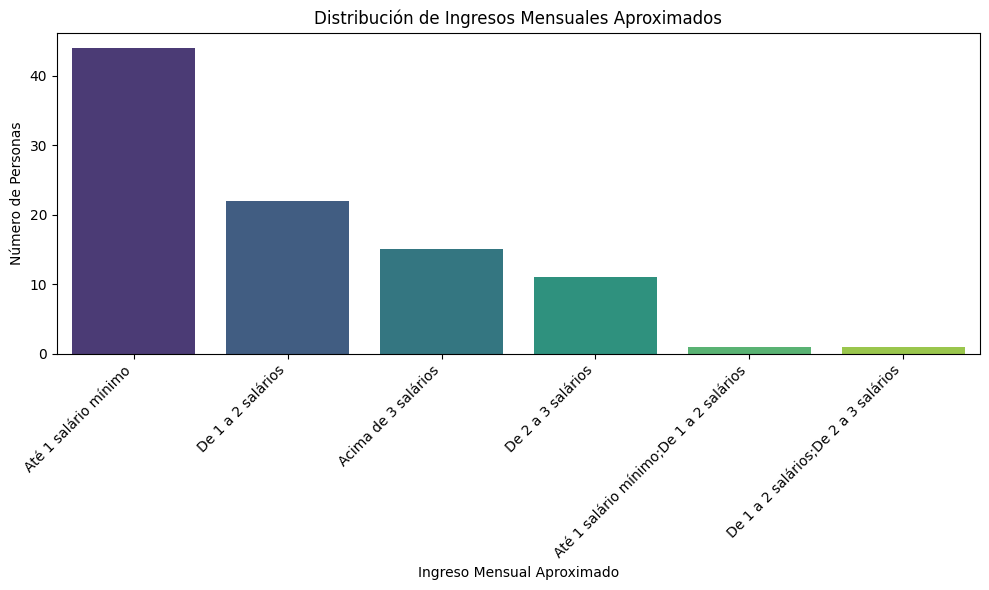

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

conteo_ingresos = df_redesSociales['Ingreso_Mensual_Aproximado'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_ingresos.index, y=conteo_ingresos.values, palette='viridis')
plt.title('Distribución de Ingresos Mensuales Aproximados')
plt.xlabel('Ingreso Mensual Aproximado')
plt.ylabel('Número de Personas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Gráfica de ocupación(ESTUDIANTES)

/tmp/ipython-input-73427868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_ocupacion.index, y=conteo_ocupacion.values, palette='magma')


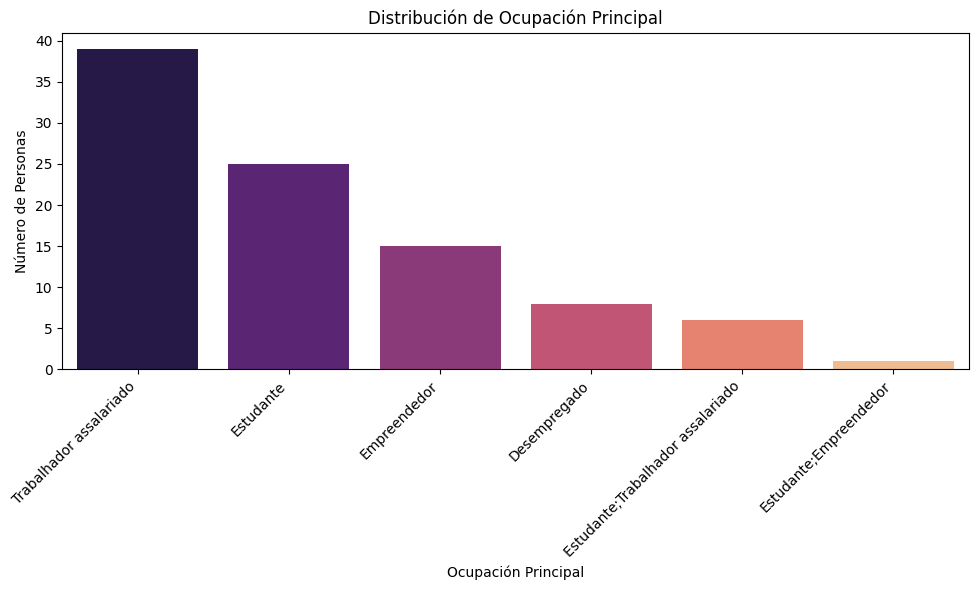

In [ ]:
conteo_ocupacion = df_redesSociales['Ocupacion_Principal'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=conteo_ocupacion.index, y=conteo_ocupacion.values, palette='magma')
plt.title('Distribución de Ocupación Principal')
plt.xlabel('Ocupación Principal')
plt.ylabel('Número de Personas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Gráfica de rango de edad que más compra

/tmp/ipython-input-2912515466.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rango_edad_compras.index, y=rango_edad_compras.values, palette='cividis')


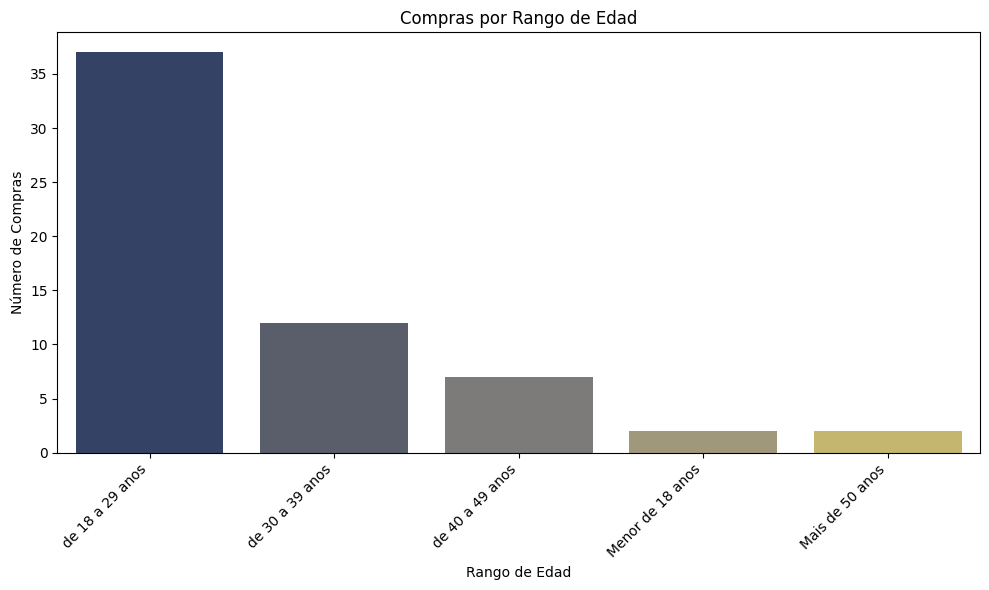

In [ ]:
rango_compras = df_redesSociales[df_redesSociales['Compra_Tras_Anuncio'] == 'Sim']
rango_edad_compras = rango_compras['Rango_Edad'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=rango_edad_compras.index, y=rango_edad_compras.values, palette='cividis')
plt.title('Compras por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Número de Compras')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Gráfica de red social mas popular

/tmp/ipython-input-2293660425.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_redes.index, y=conteo_redes.values, palette='plasma')


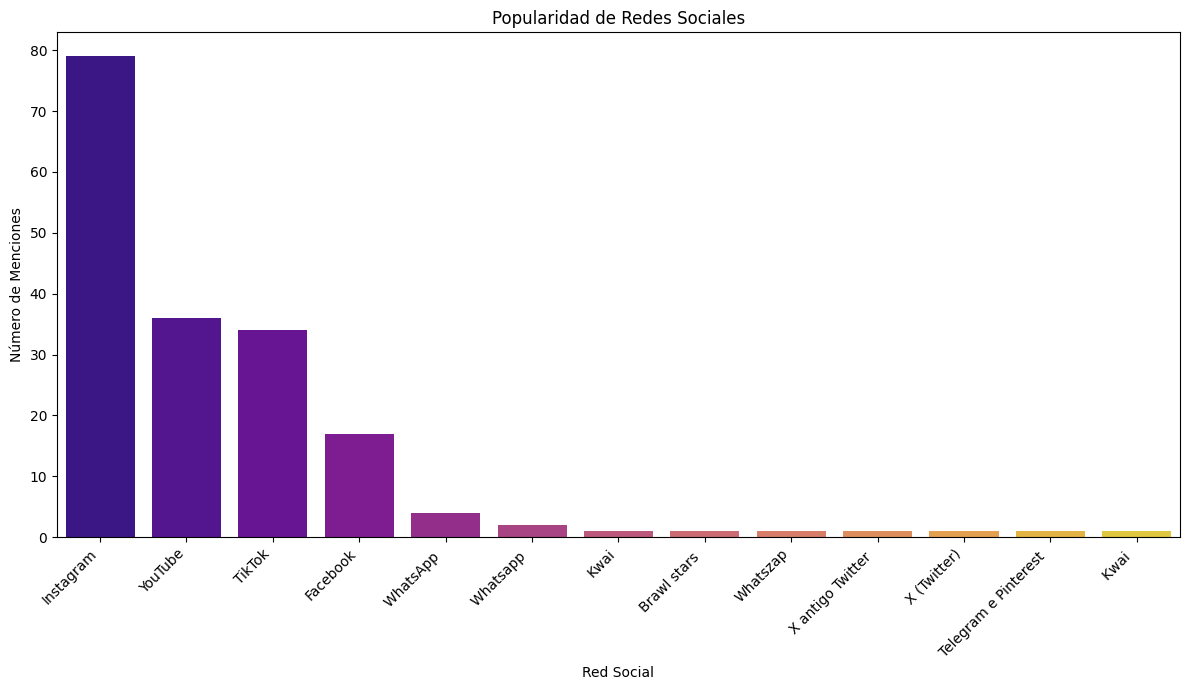

In [ ]:
temp_redes_split = df_redesSociales['Redes_Sociales_Usadas'].str.split(';', expand=True)
all_redes = temp_redes_split.stack()
conteo_redes = all_redes.value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=conteo_redes.index, y=conteo_redes.values, palette='plasma')
plt.title('Popularidad de Redes Sociales')
plt.xlabel('Red Social')
plt.ylabel('Número de Menciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Gráfica de número de compras por sexo


/tmp/ipython-input-1678014398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_sexo_compradores.index, y=conteo_sexo_compradores.values, palette='crest')


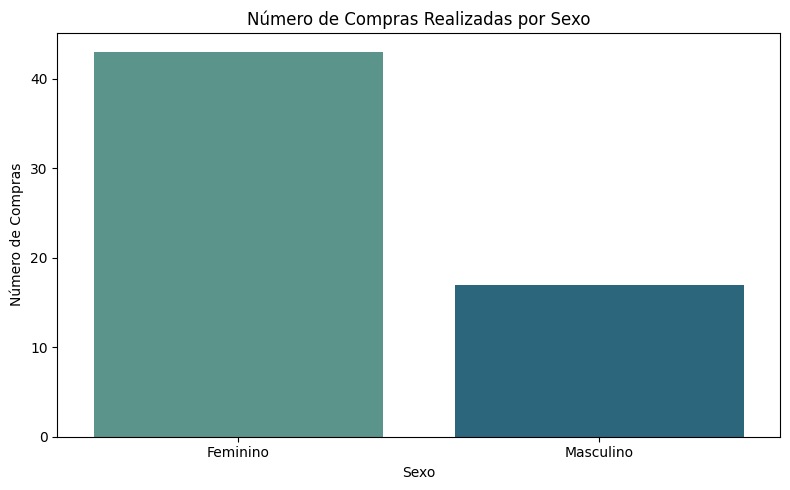

In [ ]:
compradores_por_sexo = df_redesSociales[df_redesSociales['Compra_Tras_Anuncio'] == 'Sim']
conteo_sexo_compradores = compradores_por_sexo['Sexo'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=conteo_sexo_compradores.index, y=conteo_sexo_compradores.values, palette='crest')
plt.title('Número de Compras Realizadas por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de Compras')
plt.tight_layout()
plt.show()





#Gráfica por genero masculino

/tmp/ipython-input-3136192329.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rango_edad_masculino.index, y=rango_edad_masculino.values, palette='plasma')


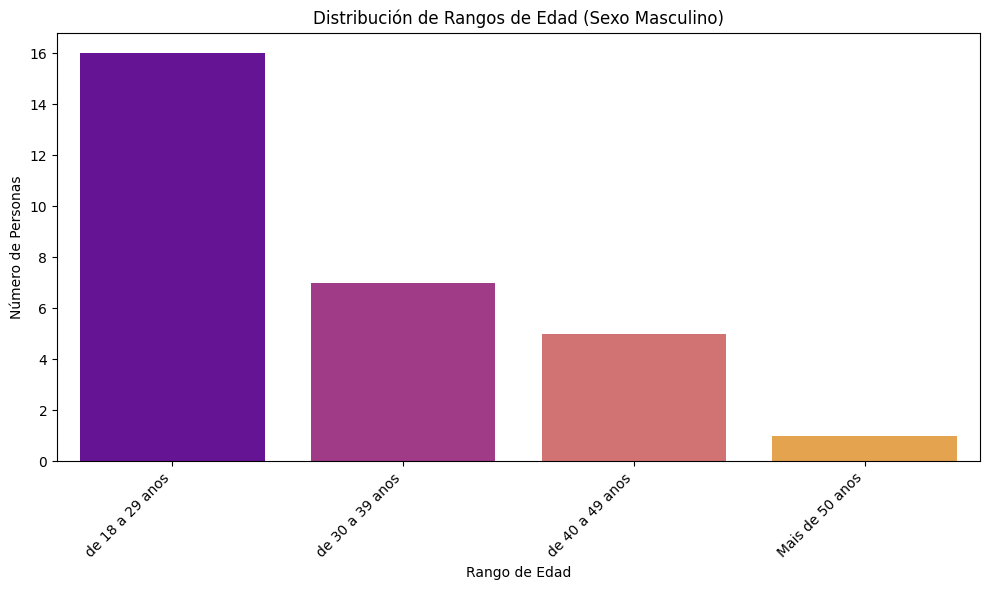

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

rango_edad_masculino = df_masculino['Rango_Edad'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=rango_edad_masculino.index, y=rango_edad_masculino.values, palette='plasma')
plt.title('Distribución de Rangos de Edad (Sexo Masculino)')
plt.xlabel('Rango de Edad')
plt.ylabel('Número de Personas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Gráfica por genero femenino

/tmp/ipython-input-1873348444.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rango_edad_femenino.index, y=rango_edad_femenino.values, palette='viridis')


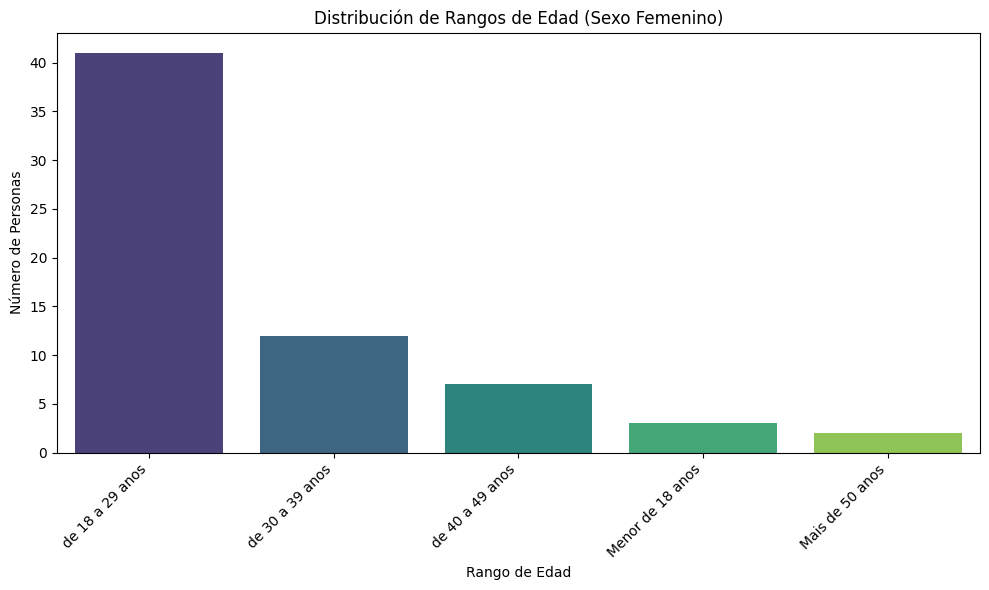

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

rango_edad_femenino = df_femenino['Rango_Edad'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=rango_edad_femenino.index, y=rango_edad_femenino.values, palette='viridis')
plt.title('Distribución de Rangos de Edad (Sexo Femenino)')
plt.xlabel('Rango de Edad')
plt.ylabel('Número de Personas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#** 3 DATOS RELEVANTES **

#NIVEL DE ESCOLARIDAD POR SEXO

In [24]:
escolaridad_por_sexo = df_redesSociales.groupby(['Sexo', 'Nivel_Escolaridad']).size().unstack(fill_value=0)
print("Distribución del Nivel de Escolaridad por Sexo:")
display(escolaridad_por_sexo)

Distribución del Nivel de Escolaridad por Sexo:


Nivel_Escolaridad,Ensino Fundamental,Ensino Fundamental;Ensino Médio,Ensino Fundamental;Ensino Médio;Ensino Superior,Ensino Médio,Ensino Superior
Sexo,,,,,
Feminino,2,3,0,23,37
Masculino,2,0,1,12,14


#GRÁFICA REPRESENTATIVA

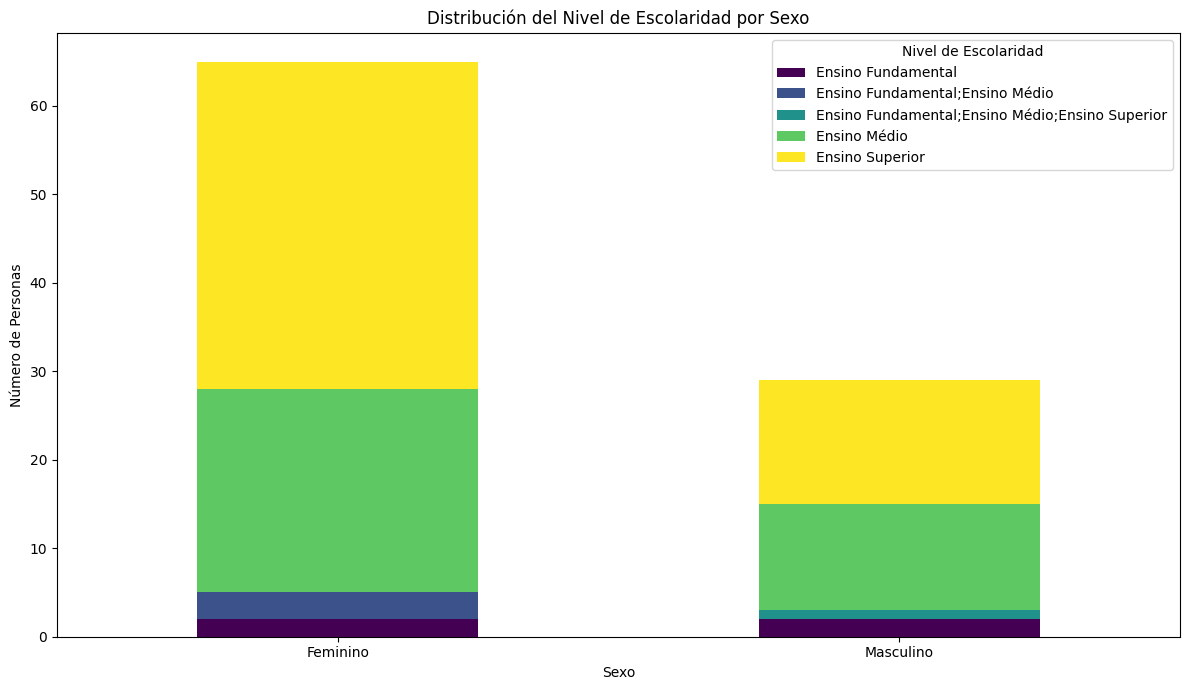

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

escolaridad_por_sexo_plot = escolaridad_por_sexo.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Distribución del Nivel de Escolaridad por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Número de Personas')
plt.xticks(rotation=0)
plt.legend(title='Nivel de Escolaridad')
plt.tight_layout()
plt.show()

#REDES SOCIALES MÁS USADAS POR RANGO DE EDAD

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Desglosar las redes sociales
temp_df = df_redesSociales[['Rango_Edad', 'Redes_Sociales_Usadas']].copy()
temp_df['Red_Social_Individual'] = temp_df['Redes_Sociales_Usadas'].str.split(';')

# Expandir la lista de redes sociales para cada rango de edad
expanded_df = temp_df.explode('Red_Social_Individual')

# Limpiar espacios en blanco si los hay
expanded_df['Red_Social_Individual'] = expanded_df['Red_Social_Individual'].str.strip()

# Estandarizar nombres de redes sociales (ej. 'Whatsapp' a 'WhatsApp')
expanded_df['Red_Social_Individual'] = expanded_df['Red_Social_Individual'].replace({'Whatsapp': 'WhatsApp'})

# Contar la ocurrencia de cada red social por rango de edad
conteo_redes_por_edad = expanded_df.groupby(['Rango_Edad', 'Red_Social_Individual']).size().unstack(fill_value=0)

print("Redes Sociales más usadas por Rango de Edad:")
display(conteo_redes_por_edad)

Redes Sociales más usadas por Rango de Edad:


Red_Social_Individual,Brawl stars,Facebook,Instagram,Kwai,Telegram e Pinterest,TikTok,WhatsApp,Whatszap,X (Twitter),X antigo Twitter,YouTube
Rango_Edad,,,,,,,,,,,
Mais de 50 anos,0,0,2,0,0,0,0,0,0,1,1
Menor de 18 anos,0,0,3,0,0,1,0,0,0,0,0
de 18 a 29 anos,1,6,51,0,1,22,2,0,1,0,20
de 30 a 39 anos,0,5,15,0,0,8,2,1,0,0,8
de 40 a 49 anos,0,6,8,2,0,3,2,0,0,0,7


#GRÁFICA REPRESENTATIVA

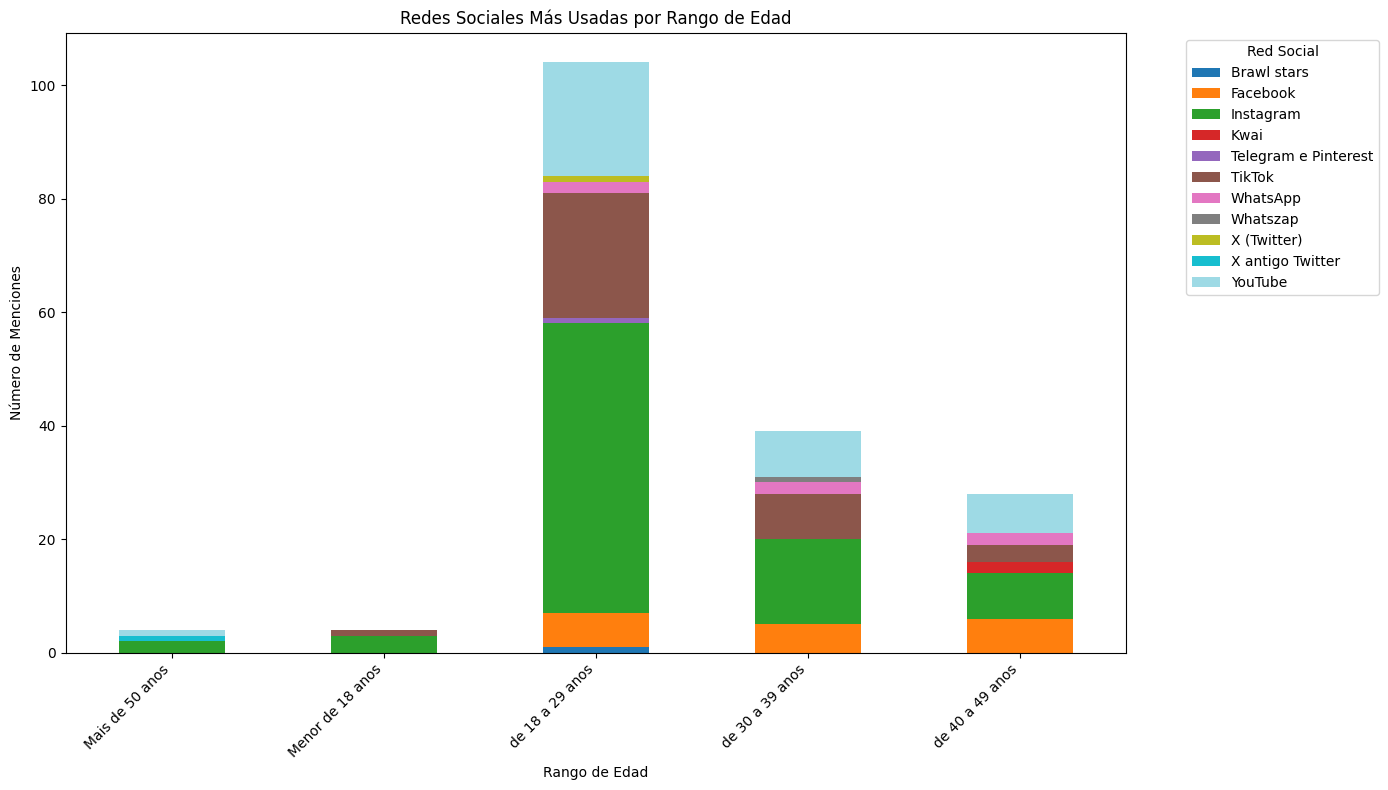

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras apiladas
conteo_redes_por_edad.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
plt.title('Redes Sociales Más Usadas por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Número de Menciones')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Red Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#TIEMPO DIARIO EN REDES SOCIALES POR NIVEL DE ESCOLARIDAD

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la ocurrencia de cada tiempo de uso por nivel de escolaridad
conteo_tiempo_por_escolaridad = df_redesSociales.groupby(['Nivel_Escolaridad', 'Tiempo_Diario_Redes_Sociales']).size().unstack(fill_value=0)

print("Distribución del Tiempo Diario en Redes Sociales por Nivel de Escolaridad:")
display(conteo_tiempo_por_escolaridad)

#GRÁFICA REPRESENTATIVA

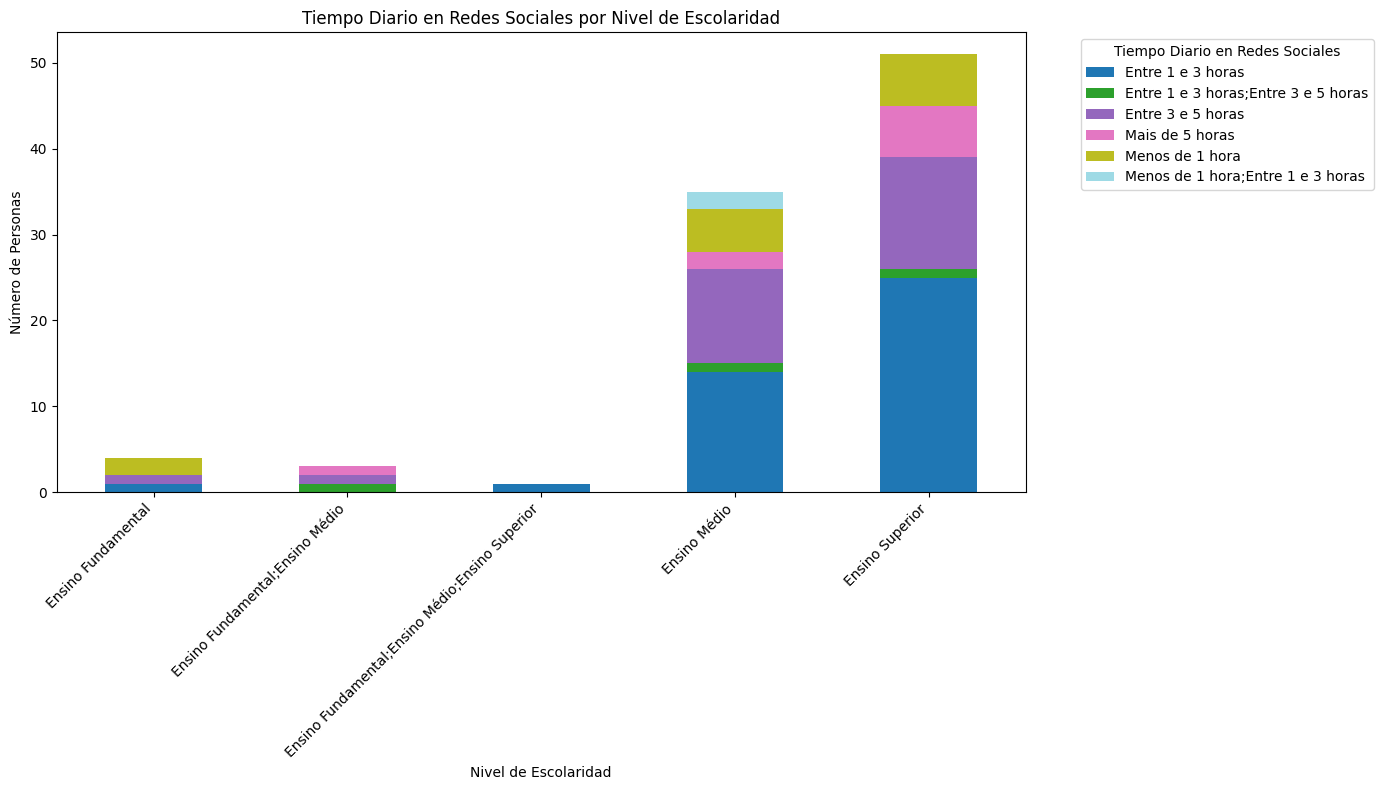

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

conteo_tiempo_por_escolaridad = df_redesSociales.groupby(['Nivel_Escolaridad', 'Tiempo_Diario_Redes_Sociales']).size().unstack(fill_value=0)
conteo_tiempo_por_escolaridad.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')
plt.title('Tiempo Diario en Redes Sociales por Nivel de Escolaridad')
plt.xlabel('Nivel de Escolaridad')
plt.ylabel('Número de Personas')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tiempo Diario en Redes Sociales', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**#INTEGRANTES**
# #RAMIREZ GONZALEZ ALVARO
# #REYES PEÑA YOCIMAR